# 第16章 連続潜在変数 (Continuous Latent Variables)
## 16.1 主成分分析 (Principal Component Analysis)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第16章「連続潜在変数」の第16.1節「主成分分析 (Principal Component Analysis: PCA)」の完全な理論解説、数式展開、Python実装、および忠実な図版再現（Figure 16.1 〜 16.6）を提供します。

---

### 目次
1. **はじめに：連続潜在変数モデルの動機**
   - 高次元データと低次元多様体仮説（Figure 16.1）
2. **16.1.1 最大分散定式化 (Maximum Variance Formulation)**
   - 標本平均と共分散行列（式 16.1, 16.3）
   - ラグランジュ未定乗数法による固有値問題への帰着（式 16.4 〜 16.6）
   - 第1主成分から第$M$主成分への数学的帰納法
3. **16.1.2 最小誤差定式化 (Minimum-Error Formulation)**
   - 完全正規直交基底による座標回転（式 16.7 〜 16.9）
   - 直交射影による二乗距離誤差 $J$ の導出（式 16.10 〜 16.15、Figure 16.2）
   - 最小誤差と固有値の和の関係（式 16.18）
4. **16.1.3 データ圧縮 (Data Compression)**
   - 主成分展開による低次元再構成（式 16.19 〜 16.21）
   - 手書き数字データに対する固有画像（Figure 16.3）
   - 固有値スペクトルと残差射影誤差 $J(M)$（Figure 16.4）
   - 次元数 $M$ による再構成精度の推移（Figure 16.5）
5. **16.1.4 データ白色化 (Data Whitening / Sphering)**
   - 相関行列と標準化（式 16.22）
   - 白色化変換 $\mathbf{y}_n = \mathbf{L}^{-1/2} \mathbf{U}^\top (\mathbf{x}_n - \bar{\mathbf{x}})$ による無相関化と単位共分散（式 16.23 〜 16.25）
   - Old Faithfulデータセットによる前処理の可視化（Figure 16.6）
6. **16.1.5 高次元データに対する双対PCA (High-Dimensional Data)**
   - $N < D$ における計算量爆発の問題点（$\mathcal{O}(D^3)$ から $\mathcal{O}(N^3)$ へ）
   - グラム行列 $N^{-1} \mathbf{X}_c \mathbf{X}_c^\top$ の固有値問題（式 16.26 〜 16.28）
   - 原空間における正規化固有ベクトルの復元公式（式 16.30）


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "16" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.principal_component_analysis import (
    PrincipalComponentAnalysis,
    whiten_data,
    dual_pca_high_dimensional,
    generate_figure_16_1,
    generate_figure_16_2,
    generate_figure_16_3,
    generate_figure_16_4,
    generate_figure_16_5,
    generate_figure_16_6,
)

setup_style()
print("Setup complete. Chapter 16 Section 16.1 modules loaded successfully.")


Setup complete. Chapter 16 Section 16.1 modules loaded successfully.


## 1. 連続潜在変数モデルの動機と低次元多様体仮説

実世界の多くの高次元データ（画像、音声、テキスト埋め込みなど）は、データ空間全体の体積を一様に満たしているのではなく、データの元々の次元数よりもはるかに低い**本質的次元（intrinsic dimensionality）**を持つ滑らかな多様体（manifold）の近傍に集中して分布しています。

### Figure 16.1: 平行移動と回転による手書き数字の3次元多様体
例えば、$100 \times 100 = 10,000$ 次元の画像空間において、1枚の手書き数字「3」にランダムな2次元平行移動（$x, y$ 座標）と回転角（$\theta$）を加えた画像群を考えます。
これら画像ベクトルは $10,000$ 次元空間の点ですが、その自由度は平行移動2自由度＋回転1自由度＝**わずか3自由度**です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_1_digit_manifold.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_1_digit_manifold.png


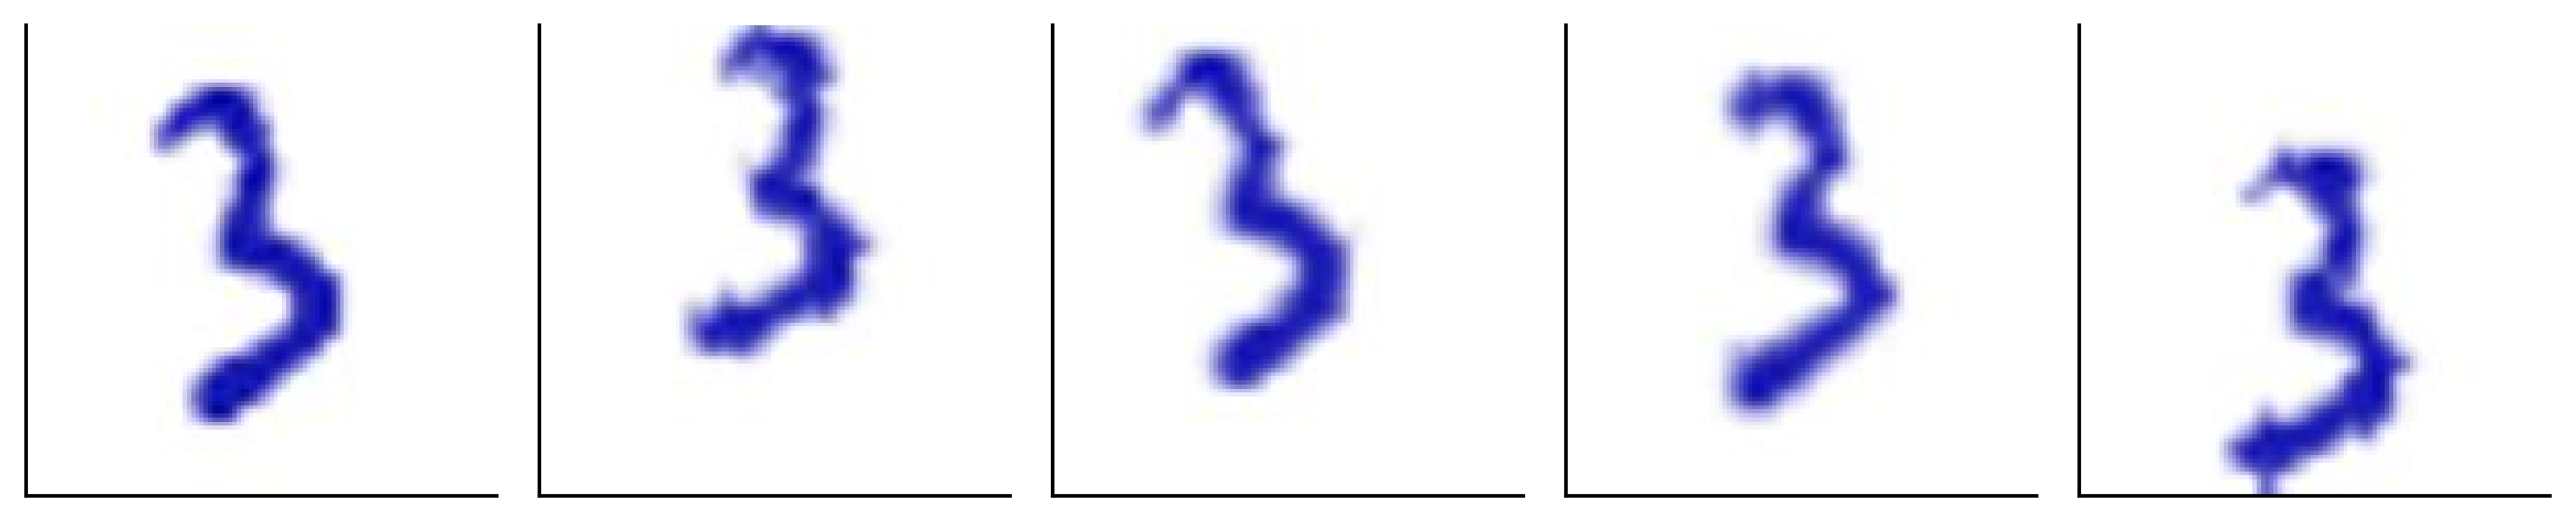

In [2]:
# Figure 16.1 の再現
fig_16_1 = generate_figure_16_1()
plt.show()


## 2. 16.1.1 最大分散定式化 (Maximum Variance Formulation)

主成分分析（Principal Component Analysis: PCA、またはコサンビ・カルーネン・レーヴェ変換）は、Hotelling (1933) によって**射影後のデータの分散を最大化する線形射影**として定義されました。

### 1次元主部分空間への射影
$D$ 次元のデータ集合 $\{\mathbf{x}_n\}_{n=1}^N$ に対し、単位長ベクトル $\mathbf{u}_1$（$\mathbf{u}_1^\top \mathbf{u}_1 = 1$）で指定される1次元部分空間を考えます。
各データ点 $\mathbf{x}_n$ の射影値はスカラー $\mathbf{u}_1^\top \mathbf{x}_n$ となり、その標本平均は：
$$
\bar{\mathbf{x}} = \frac{1}{N} \sum_{n=1}^N \mathbf{x}_n \quad (\text{式 } 16.1)
$$
を用いて $\mathbf{u}_1^\top \bar{\mathbf{x}}$ と表されます。射影データの標本分散は：
$$
\frac{1}{N} \sum_{n=1}^N (\mathbf{u}_1^\top \mathbf{x}_n - \mathbf{u}_1^\top \bar{\mathbf{x}})^2 = \mathbf{u}_1^\top \mathbf{S} \mathbf{u}_1 \quad (\text{式 } 16.2)
$$
ここで $\mathbf{S}$ はデータの標本共分散行列（$D \times D$）です：
$$
\mathbf{S} = \frac{1}{N} \sum_{n=1}^N (\mathbf{x}_n - \bar{\mathbf{x}})(\mathbf{x}_n - \bar{\mathbf{x}})^\top \quad (\text{式 } 16.3)
$$

### ラグランジュ未定乗数法による最適化
$\|\mathbf{u}_1\| \to \infty$ への発散を防ぐため、単位ノルム制約 $\mathbf{u}_1^\top \mathbf{u}_1 = 1$ をラグランジュ乗数 $\lambda_1$ で組み込みます：
$$
\widetilde{J}(\mathbf{u}_1, \lambda_1) = \mathbf{u}_1^\top \mathbf{S} \mathbf{u}_1 + \lambda_1 (1 - \mathbf{u}_1^\top \mathbf{u}_1) \quad (\text{式 } 16.4)
$$
$\mathbf{u}_1$ について微分してゼロとおくと：
$$
\nabla_{\mathbf{u}_1} \widetilde{J} = 2 \mathbf{S} \mathbf{u}_1 - 2 \lambda_1 \mathbf{u}_1 = \mathbf{0} \implies \mathbf{S} \mathbf{u}_1 = \lambda_1 \mathbf{u}_1 \quad (\text{式 } 16.5)
$$
すなわち、$\mathbf{u}_1$ は共分散行列 $\mathbf{S}$ の**固有ベクトル**でなければなりません。左から $\mathbf{u}_1^\top$ を乗じると：
$$
\mathbf{u}_1^\top \mathbf{S} \mathbf{u}_1 = \lambda_1 \quad (\text{式 } 16.6)
$$
となり、射影分散は固有値 $\lambda_1$ そのものに一致します。したがって、分散を最大化するためには、**最大固有値 $\lambda_1$ に対応する固有ベクトル**を $\mathbf{u}_1$（第1主成分）として選択すべきであることが証明されます。

### 一般の $M$ 次元主部分空間
$M$ 次元の射影空間への一般化は、既知の主成分と直交する空間の中で分散最大方向を順次選択する数学的帰納法により、**最大固有値から順に選んだ $M$ 本の固有ベクトル $\mathbf{u}_1, \dots, \mathbf{u}_M$** が最適線形部分空間を張ることが示されます。


In [3]:
# 最大分散定式化の数値検証
rng = np.random.RandomState(42)
true_cov = np.array([[3.0, 1.5], [1.5, 1.0]])
X_synth = rng.multivariate_normal(mean=[2.0, -1.0], cov=true_cov, size=500)

pca = PrincipalComponentAnalysis(n_components=2)
pca.fit(X_synth)

X_c = X_synth - pca.mean_
S = (X_c.T @ X_c) / len(X_synth)

# 各主軸方向への射影分散の計算
proj_var_1 = float(pca.components_[0] @ S @ pca.components_[0])
proj_var_2 = float(pca.components_[1] @ S @ pca.components_[1])

print(f"Sample mean x_bar: {pca.mean_}")
print(f"Eigenvalue lambda_1: {pca.explained_variance_[0]:.4f}, Projected variance u_1^T S u_1: {proj_var_1:.4f}")
print(f"Eigenvalue lambda_2: {pca.explained_variance_[1]:.4f}, Projected variance u_2^T S u_2: {proj_var_2:.4f}")

assert np.isclose(proj_var_1, pca.explained_variance_[0])
assert np.isclose(proj_var_2, pca.explained_variance_[1])
print("Maximum variance formulation verified successfully.")


Sample mean x_bar: [ 1.98646086 -0.98958474]
Eigenvalue lambda_1: 3.5492, Projected variance u_1^T S u_1: 3.5492
Eigenvalue lambda_2: 0.1935, Projected variance u_2^T S u_2: 0.1935
Maximum variance formulation verified successfully.


## 3. 16.1.2 最小誤差定式化 (Minimum-Error Formulation)

Pearson (1901) によるもう1つの等価な定式化は、**データ点とその低次元直交射影との間の平均二乗ユークリッド距離（射影誤差）を最小化する**という幾何学的アプローチです。

### Figure 16.2: 主部分空間への直交射影と誤差ベクトル


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_2_pca_projection_schematic.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_2_pca_projection_schematic.png


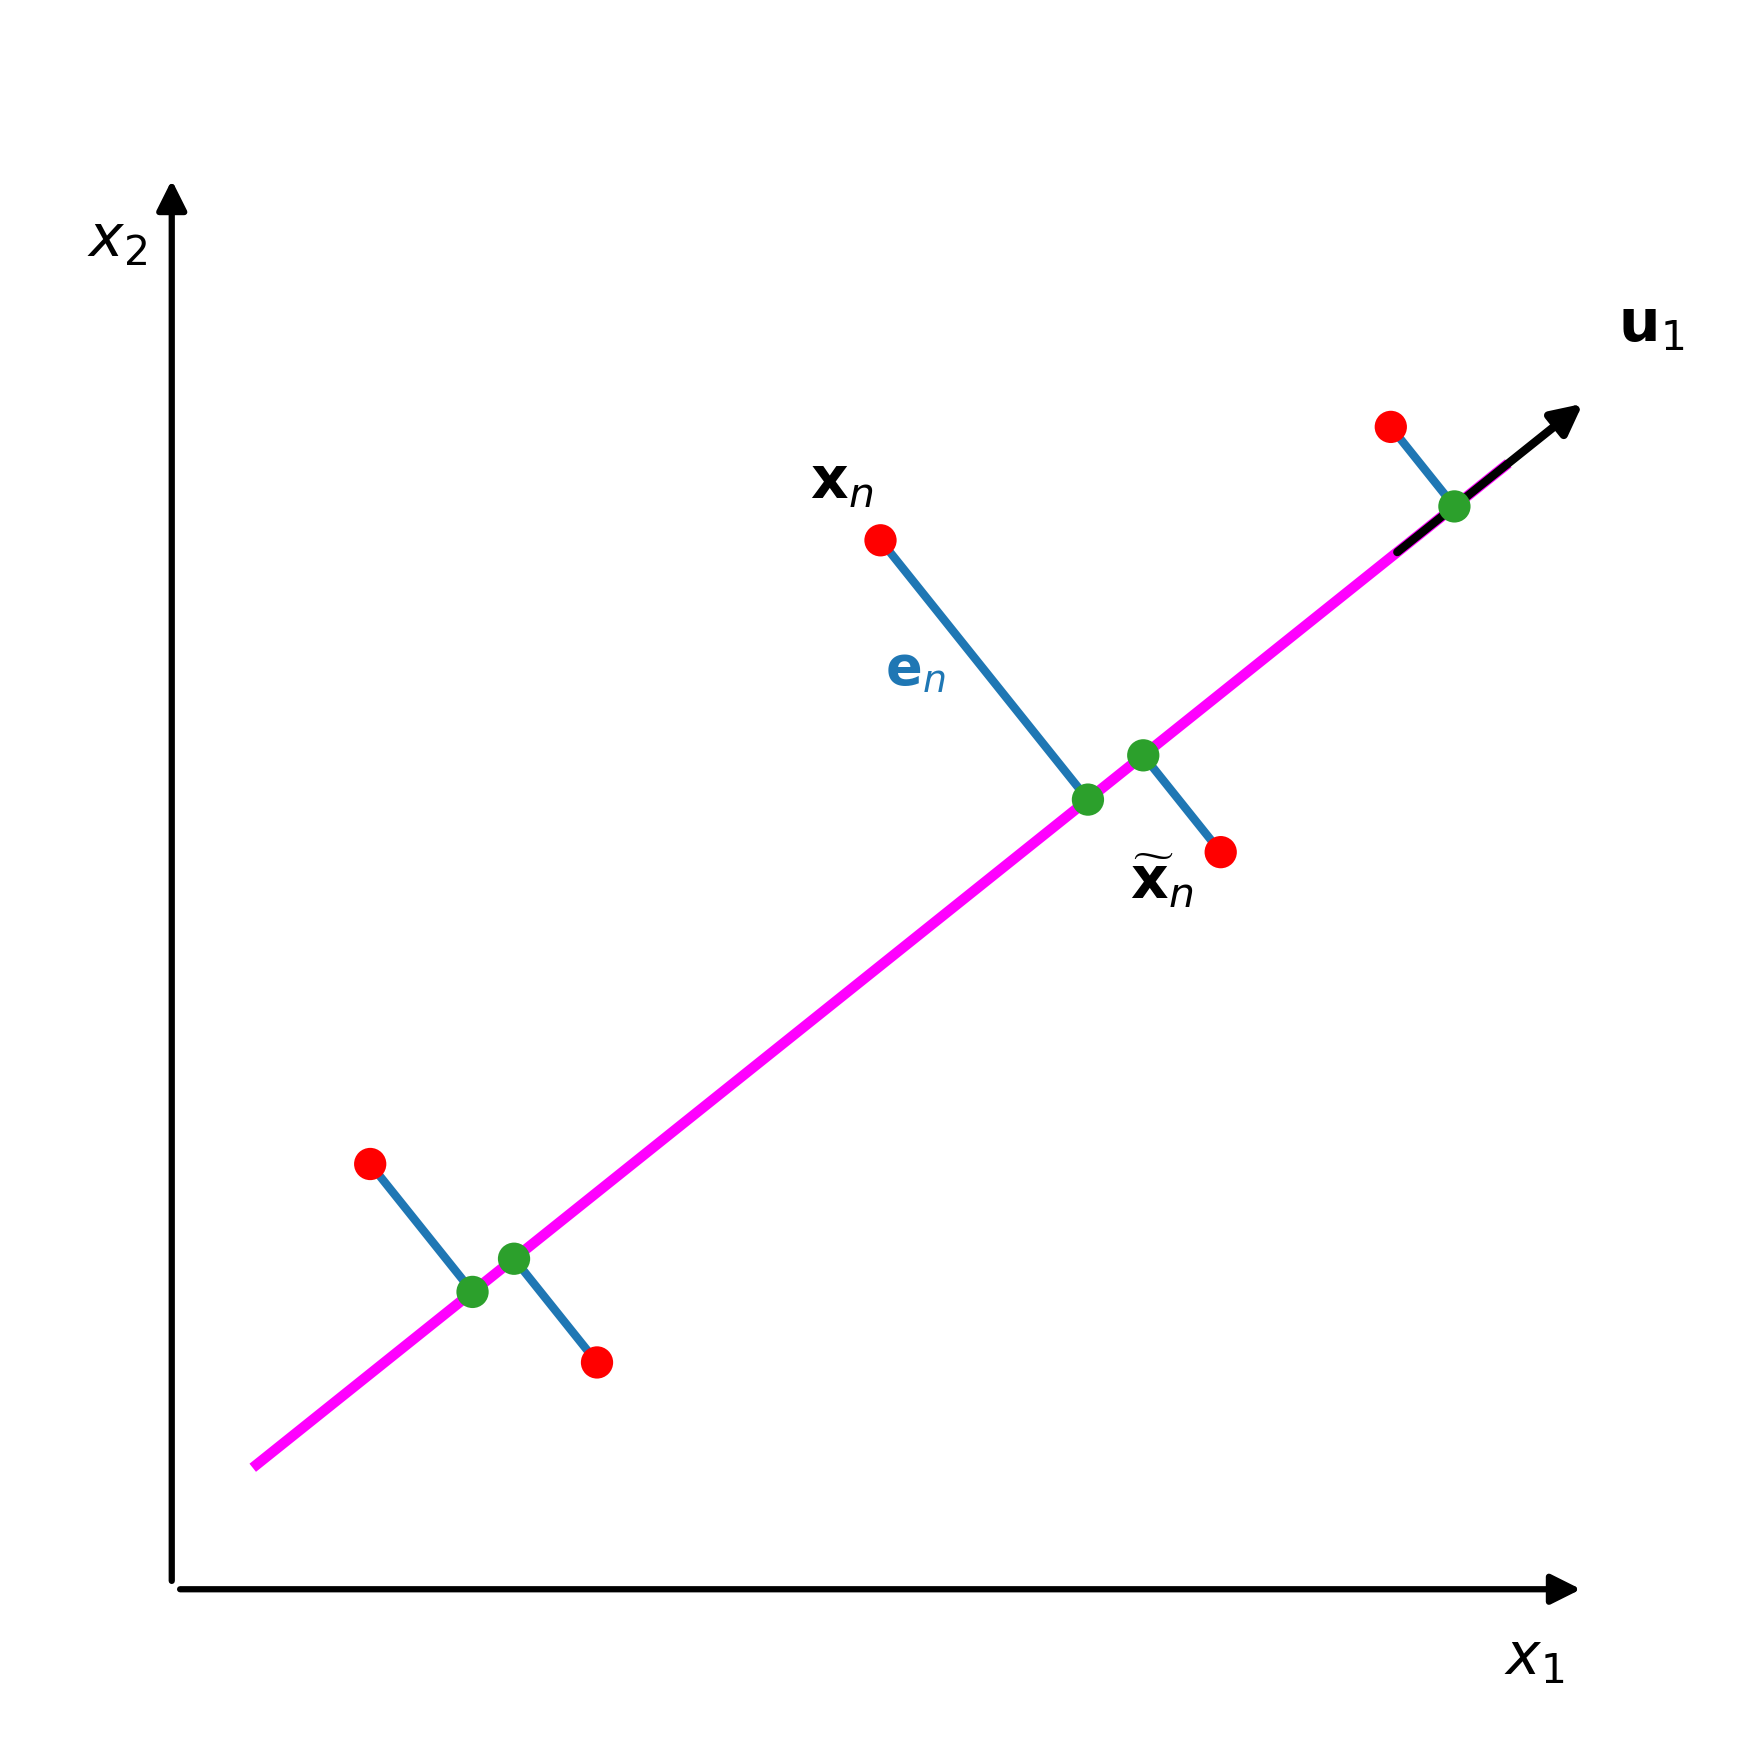

In [4]:
# Figure 16.2 の再現
fig_16_2 = generate_figure_16_2()
plt.show()


### 射影誤差最小化の厳密な数式展開
$D$ 次元空間の完全正規直交基底 $\{\mathbf{u}_i\}_{i=1}^D$（$\mathbf{u}_i^\top \mathbf{u}_j = \delta_{ij}$、式 16.7）を用いると、任意のデータ点 $\mathbf{x}_n$ は基底の線形結合として厳密に表現できます：
$$
\mathbf{x}_n = \sum_{i=1}^D (\mathbf{x}_n^\top \mathbf{u}_i) \mathbf{u}_i \quad (\text{式 } 16.9)
$$
これを $M < D$ 次元の主部分空間で近似する表現 $\widetilde{\mathbf{x}}_n$ を定義します：
$$
\widetilde{\mathbf{x}}_n = \sum_{i=1}^M z_{ni} \mathbf{u}_i + \sum_{i=M+1}^D b_i \mathbf{u}_i \quad (\text{式 } 16.10)
$$
ここで $\{z_{ni}\}$ はデータ点ごとに固有の座標であり、$\{b_i\}$ は全データ点に共通の定数です。
目的関数である平均二乗誤差 $J$ は：
$$
J = \frac{1}{N} \sum_{n=1}^N \|\mathbf{x}_n - \widetilde{\mathbf{x}}_n\|^2 \quad (\text{式 } 16.11)
$$
1. $z_{nj}$ についての最小化：$\frac{\partial J}{\partial z_{nj}} = 0 \implies z_{nj} = \mathbf{x}_n^\top \mathbf{u}_j$（式 16.12）
2. $b_j$ についての最小化：$\frac{\partial J}{\partial b_j} = 0 \implies b_j = \bar{\mathbf{x}}^\top \mathbf{u}_j$（式 16.13）
これらを代入すると、誤差ベクトルは**主部分空間に直交する補空間の基底**のみで展開されます：
$$
\mathbf{x}_n - \widetilde{\mathbf{x}}_n = \sum_{i=M+1}^D (\mathbf{x}_n - \bar{\mathbf{x}})^\top \mathbf{u}_i \mathbf{u}_i \quad (\text{式 } 16.14)
$$
直交性 $\mathbf{u}_i^\top \mathbf{u}_j = \delta_{ij}$ より、二乗和誤差は以下のように共分散行列の2次形式の和に帰着します：
$$
J = \frac{1}{N} \sum_{n=1}^N \sum_{i=M+1}^D \left[ (\mathbf{x}_n - \bar{\mathbf{x}})^\top \mathbf{u}_i \right]^2 = \sum_{i=M+1}^D \mathbf{u}_i^\top \mathbf{S} \mathbf{u}_i \quad (\text{式 } 16.15)
$$
制約条件 $\mathbf{u}_i^\top \mathbf{u}_i = 1$ のもとで $J$ を最小化する固有ベクトルを選ぶと、停留条件 $\mathbf{S} \mathbf{u}_i = \lambda_i \mathbf{u}_i$ が得られ、誤差関数の最小値は**捨てられた $D - M$ 個の固有値の和**となります：
$$
J_{\min} = \sum_{i=M+1}^D \lambda_i \quad (\text{式 } 16.18)
$$
したがって、誤差 $J$ を最小化するためには、最も小さい $D - M$ 個の固有値に対応する方向を捨て、**最も大きい $M$ 個の固有値に対応する固有ベクトル $\mathbf{u}_1, \dots, \mathbf{u}_M$ を主部分空間として採用**しなければなりません。
これにより、**最大分散定式化と最小誤差定式化が数学的に完全に同一の解を導く**ことが示されました。


In [5]:
# 最小誤差定式化の数値検証: J == sum_{i=M+1}^D lambda_i
rng = np.random.RandomState(42)
D = 6
N = 200
X_synth = rng.randn(N, D) @ rng.randn(D, D)

for M in [1, 2, 4]:
    pca_m = PrincipalComponentAnalysis(n_components=M)
    pca_m.fit(X_synth)
    empirical_J = pca_m.reconstruction_error(X_synth)

    # 全固有値の計算
    pca_full = PrincipalComponentAnalysis(n_components=D)
    pca_full.fit(X_synth)
    theoretical_J = float(np.sum(pca_full.explained_variance_[M:]))

    print(f"M = {M}: Empirical J = {empirical_J:.6f}, Theoretical sum of discarded eigenvalues = {theoretical_J:.6f}")
    assert np.isclose(empirical_J, theoretical_J, rtol=1e-5)

print("Minimum error formulation and eigenvalue sum relationship verified successfully.")


M = 1: Empirical J = 17.991505, Theoretical sum of discarded eigenvalues = 17.991505
M = 2: Empirical J = 8.861523, Theoretical sum of discarded eigenvalues = 8.861523
M = 4: Empirical J = 0.183456, Theoretical sum of discarded eigenvalues = 0.183456
Minimum error formulation and eigenvalue sum relationship verified successfully.


## 4. 16.1.3 データ圧縮と低次元再構成 (Data Compression)

PCAは可逆的な直交回転ではなく、下位の成分を切り捨てることで情報の一部を破棄する**不可逆データ圧縮（lossy compression）**技術として利用されます。
各データ点 $\mathbf{x}_n \in \mathbb{R}^D$ は、$M$ 次元の低次元表現ベクトル：
$$
z_{ni} = (\mathbf{x}_n - \bar{\mathbf{x}})^\top \mathbf{u}_i \quad (i = 1, \dots, M)
$$
に圧縮され、再構成は以下の式 (16.20) によって行われます：
$$
\widetilde{\mathbf{x}}_n = \bar{\mathbf{x}} + \sum_{i=1}^M z_{ni} \mathbf{u}_i \quad (\text{式 } 16.20)
$$

### Figure 16.3: 手書き数字「3」に対する平均画像と第1〜第4主成分固有ベクトル
手書き数字「3」の $28 \times 28 = 784$ 次元画像 6,000 枚に対する平均画像 $\bar{\mathbf{x}}$ と、上位4つの固有ベクトル $\mathbf{u}_1, \dots, \mathbf{u}_4$（固有画像: eigenimages）および固有値 $\lambda_1, \dots, \lambda_4$ を示します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_3_pca_eigenvectors.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_3_pca_eigenvectors.png


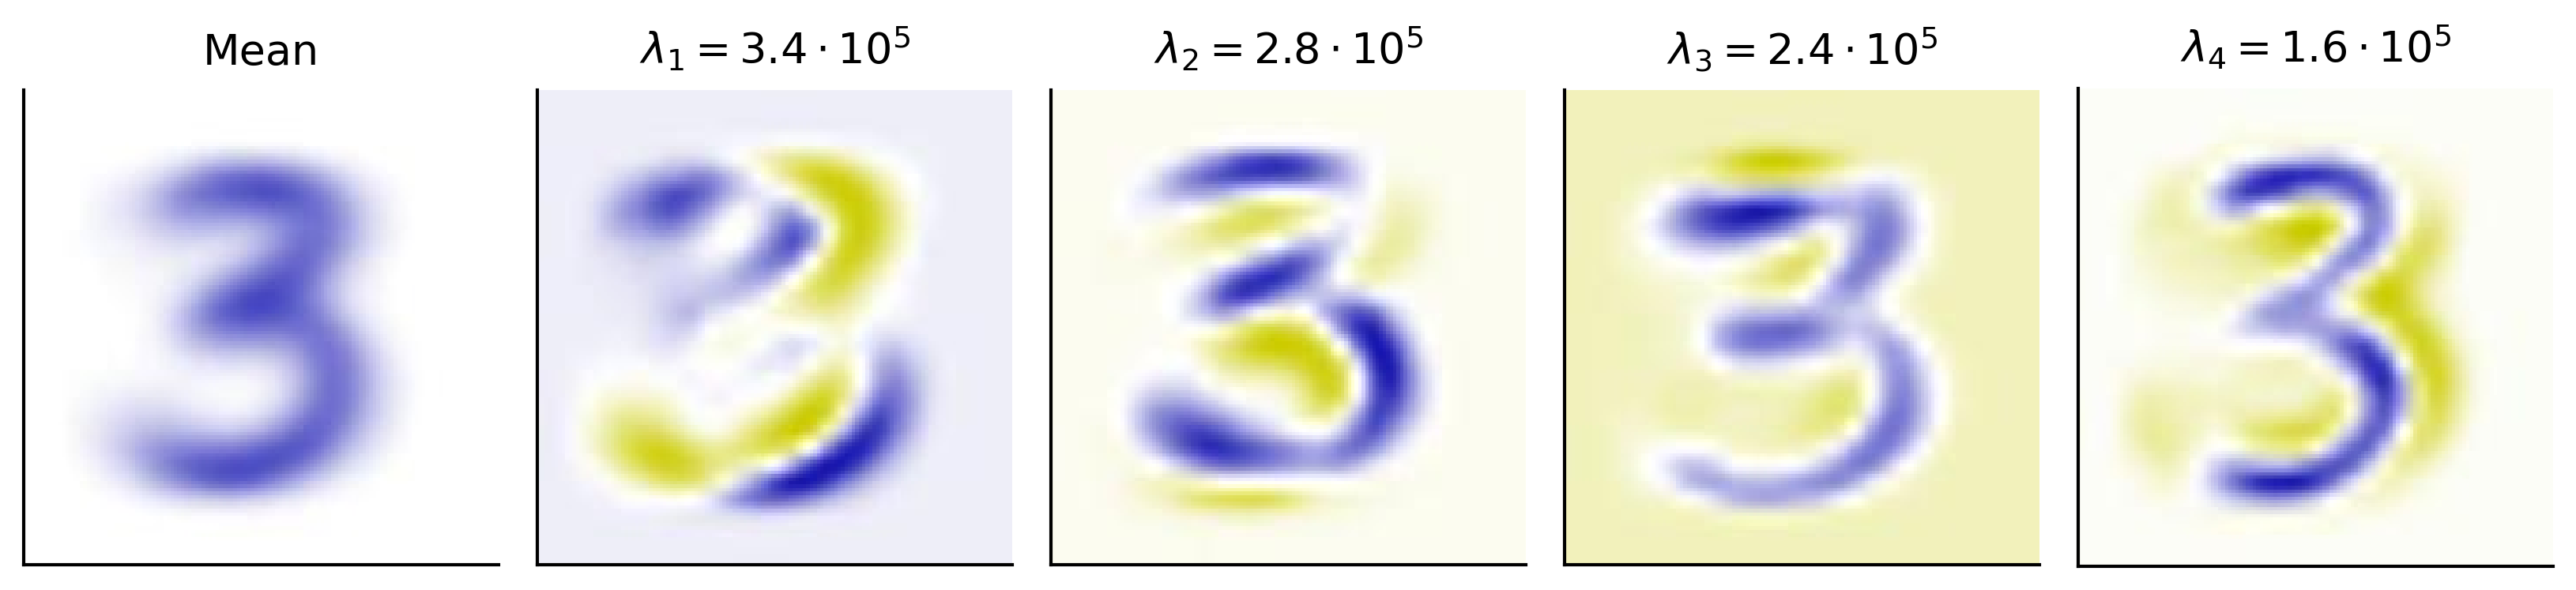

In [6]:
# Figure 16.3 の再現
fig_16_3 = generate_figure_16_3()
plt.show()


### Figure 16.4: 固有値スペクトルと累積残差誤差 $J(M)$
- **(a) 固有値スペクトル**: 固有値 $\lambda_i$ を降順にプロットしたもの。先頭の数成分が急激に減衰し、大部分の分散が低次元部分空間に集中していることが分かります。
- **(b) 残差二乗誤差 $J$**: 保持する次元数 $M$ を増やしたときの残差二乗誤差 $J(M) = \sum_{i=M+1}^{784} \lambda_i$。$M \approx 50 \sim 100$ で急激にゼロに近づきます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_4_eigenvalue_spectrum_and_error.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_4_eigenvalue_spectrum_and_error.png


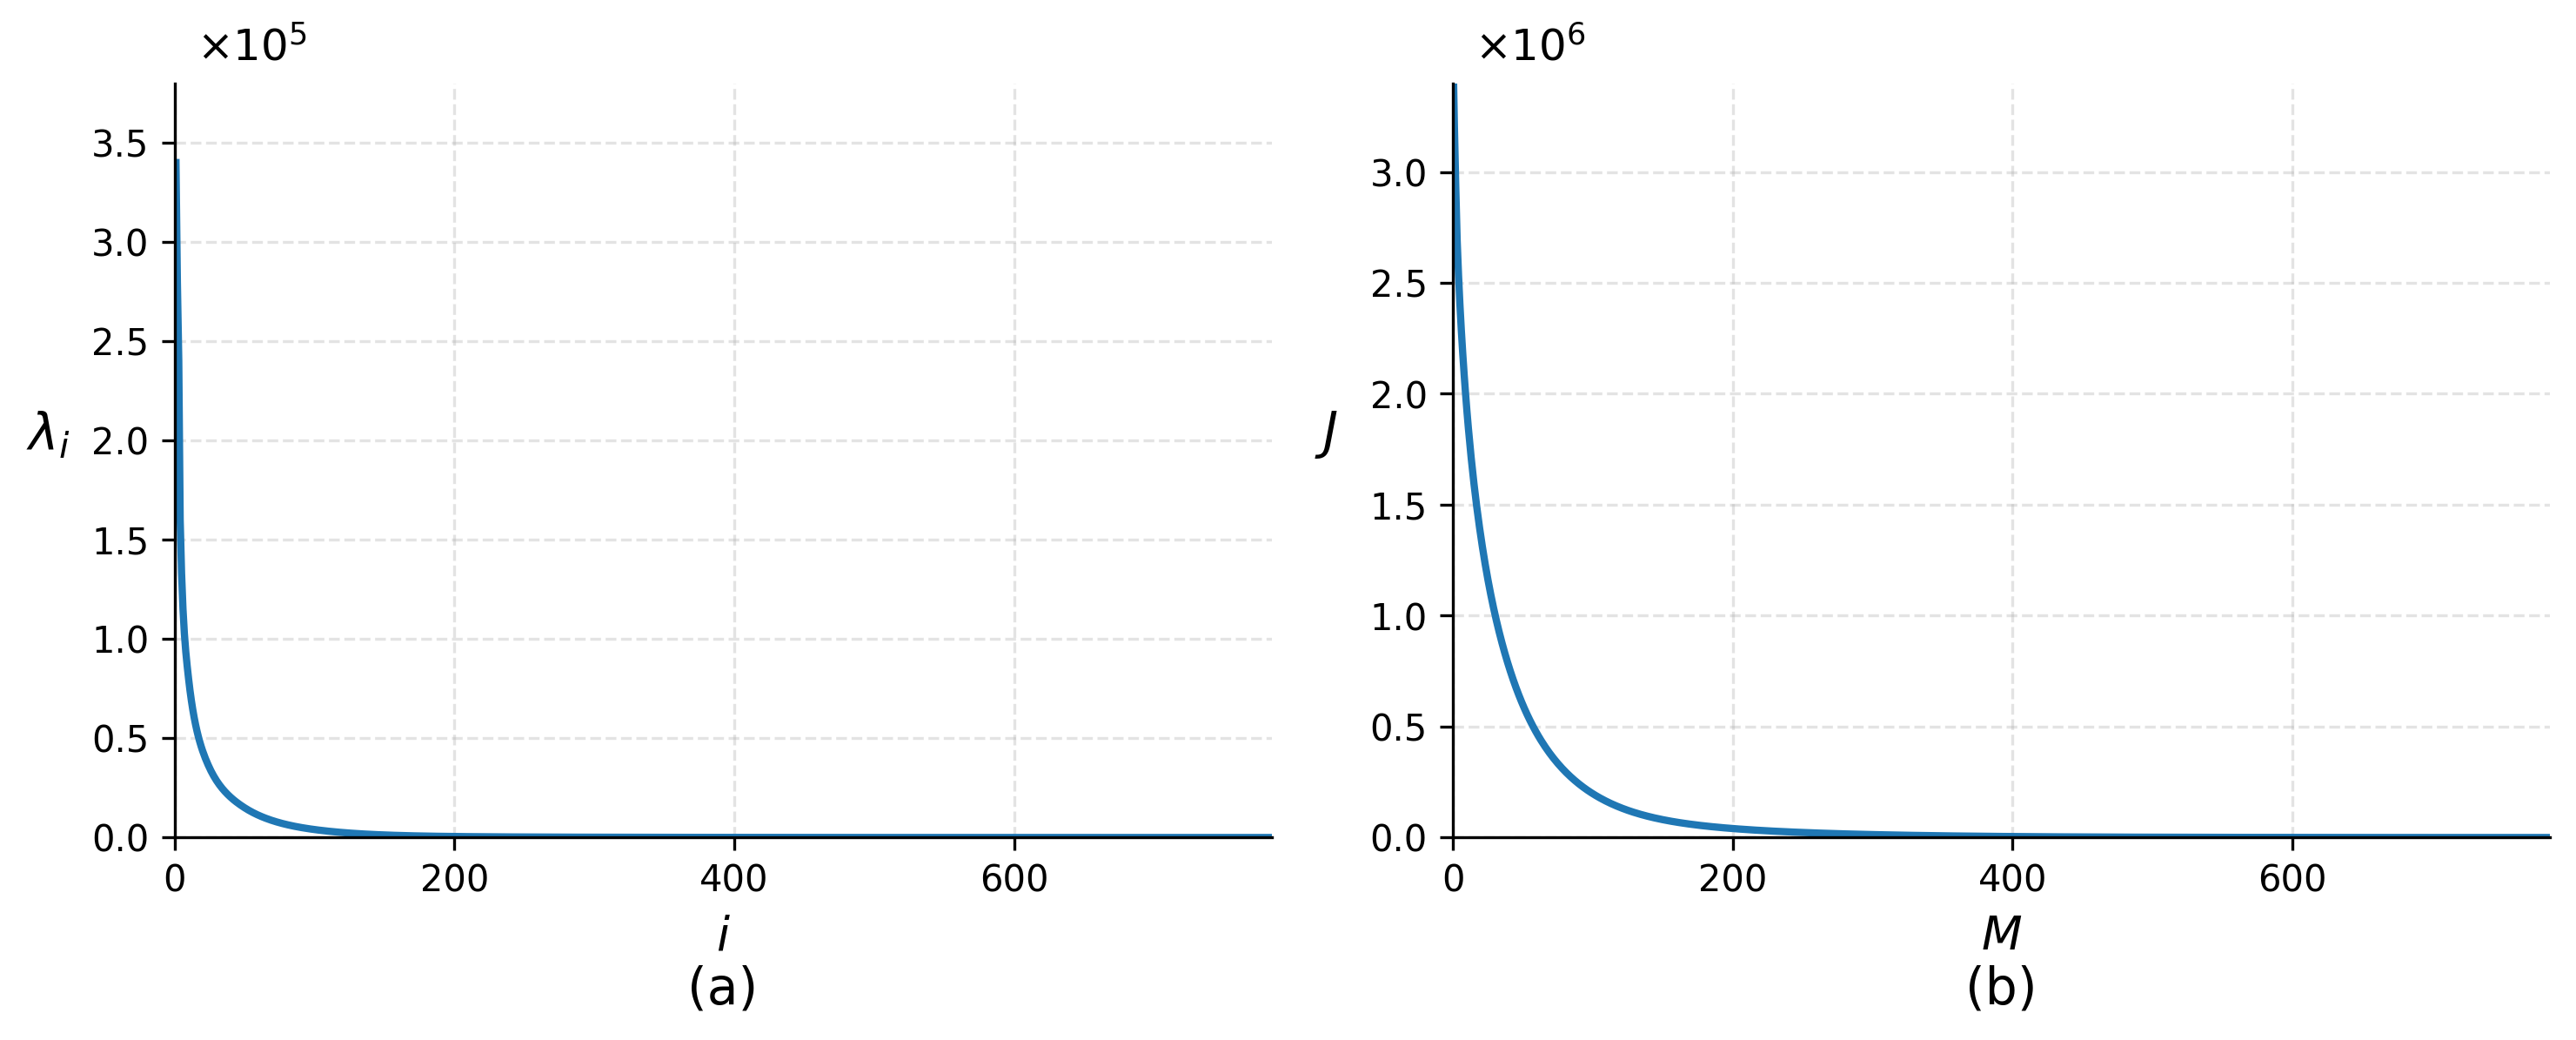

In [7]:
# Figure 16.4 の再現
fig_16_4 = generate_figure_16_4()
plt.show()


### Figure 16.5: 保持する主成分数 $M$ に伴う手書き数字画像の再構成推移
元画像（Original）に対し、$M = 1, 10, 50, 250$ 個の主成分を用いて再構成した画像です。
$M=1$ では平均的な「3」のぼやけたシルエットですが、$M=50$ でほぼ判読可能となり、$M=250$ では元画像と視覚的に区別がつかない高品質な再構成が得られます。$M=D=784$ で再構成は完全に一致（$J=0$）します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_5_digit_reconstruction.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_5_digit_reconstruction.png


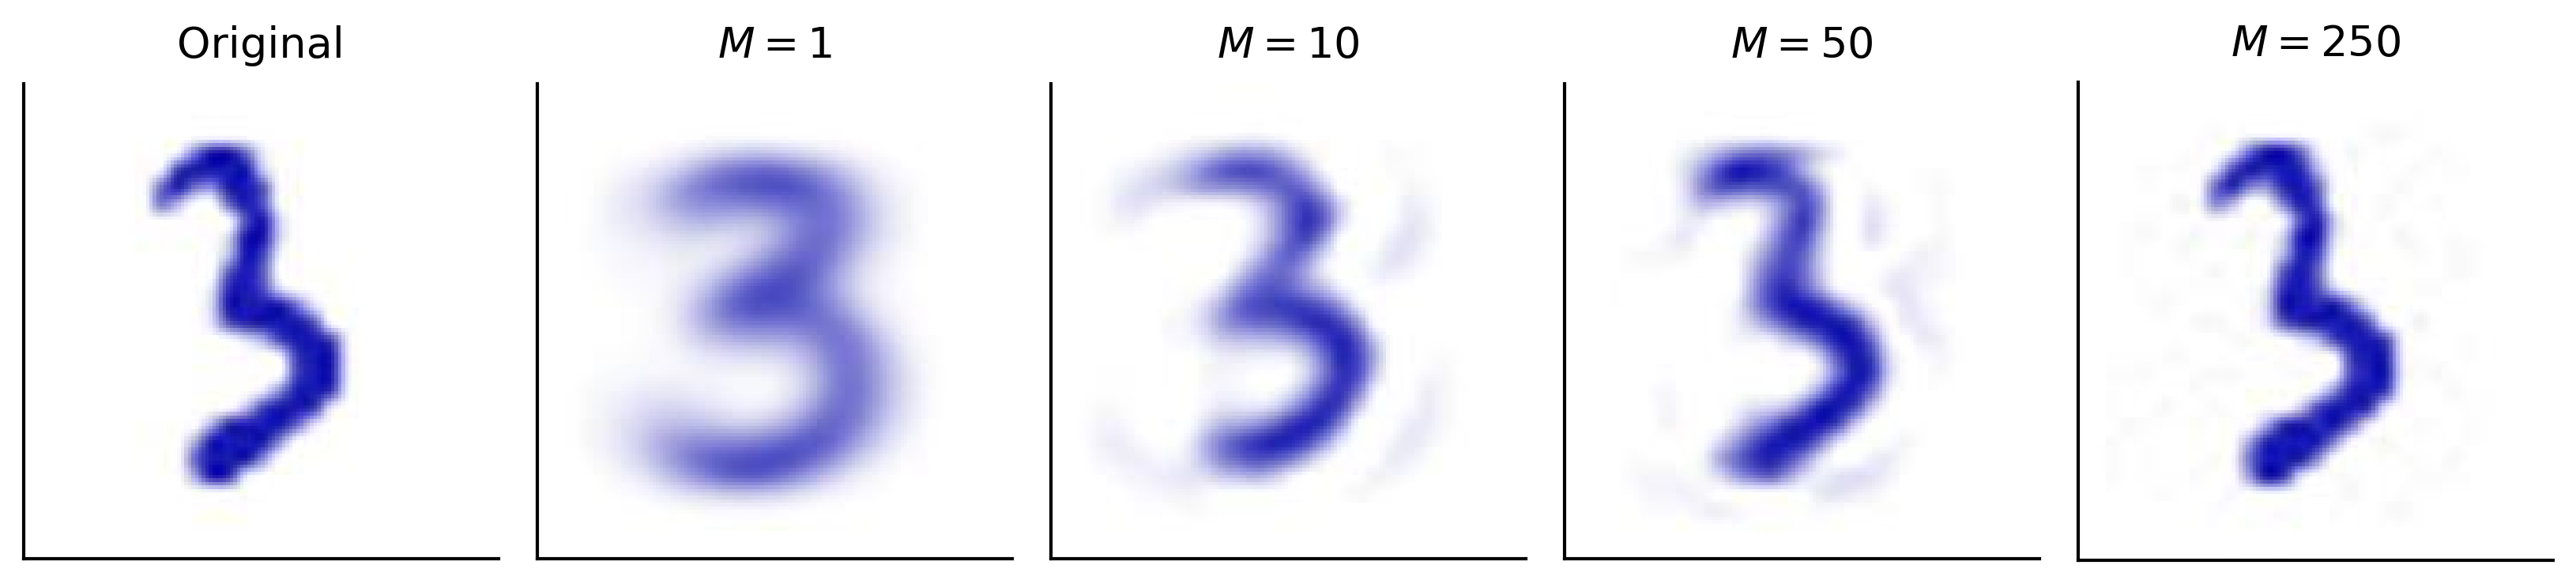

In [8]:
# Figure 16.5 の再現
fig_16_5 = generate_figure_16_5()
plt.show()


## 5. 16.1.4 データ白色化 (Data Whitening / Sphering)

PCAのもう1つの重要な応用は、次元削減ではなく**データの前処理（白色化 / 球面化: whitening / sphering）**です。
各変数の測定単位やスケールが大きく異なる場合、まず各次元を平均ゼロ・分散1に標準化（standardize）します：
$$
\rho_{ij} = \frac{1}{N} \sum_{n=1}^N \frac{(x_{ni} - \bar{x}_i)}{\sigma_i} \frac{(x_{nj} - \bar{x}_j)}{\sigma_j} \quad (\text{式 } 16.22)
$$
しかし、標準化だけでは変数間の相関（非対角成分）は残ります。PCAを用いることで、**平均ゼロかつ単位共分散行列 $\mathbf{I}$ を持つ完全無相関な表現**へと変換できます。

### 白色化変換の導出
固有方程式を行列形式 $\mathbf{S} \mathbf{U} = \mathbf{U} \mathbf{L}$（式 16.23）と書きます（$\mathbf{L} = \operatorname{diag}(\lambda_i)$、$\mathbf{U}$ は直交行列）。
白色化ベクトル $\mathbf{y}_n$ を次のように定義します：
$$
\mathbf{y}_n = \mathbf{L}^{-1/2} \mathbf{U}^\top (\mathbf{x}_n - \bar{\mathbf{x}}) \quad (\text{式 } 16.24)
$$
このとき、$\{\mathbf{y}_n\}$ の標本共分散行列を計算すると：
$$
\frac{1}{N} \sum_{n=1}^N \mathbf{y}_n \mathbf{y}_n^\top = \frac{1}{N} \sum_{n=1}^N \mathbf{L}^{-1/2} \mathbf{U}^\top (\mathbf{x}_n - \bar{\mathbf{x}})(\mathbf{x}_n - \bar{\mathbf{x}})^\top \mathbf{U} \mathbf{L}^{-1/2}
$$
$$
= \mathbf{L}^{-1/2} \mathbf{U}^\top \mathbf{S} \mathbf{U} \mathbf{L}^{-1/2} = \mathbf{L}^{-1/2} \mathbf{L} \mathbf{L}^{-1/2} = \mathbf{I} \quad (\text{式 } 16.25)
$$
となり、共分散行列は厳密に単位行列 $\mathbf{I}$ となります。

### Figure 16.6: Old Faithfulデータセットにおける線形前処理の効果
- **左図**: 元データ（噴出時間 $x_1 \in [1, 6]$ 分 vs 待機時間 $x_2 \in [40, 100]$ 分）
- **中央図**: 各次元を平均ゼロ・分散1に独立標準化したデータと、主軸ベクトル（長さ $\pm \lambda_i^{1/2}$）
- **右図**: 白色化変換後のデータ（原点を中心に等方的な球面状に無相関化）


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_6_data_whitening.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_6_data_whitening.png


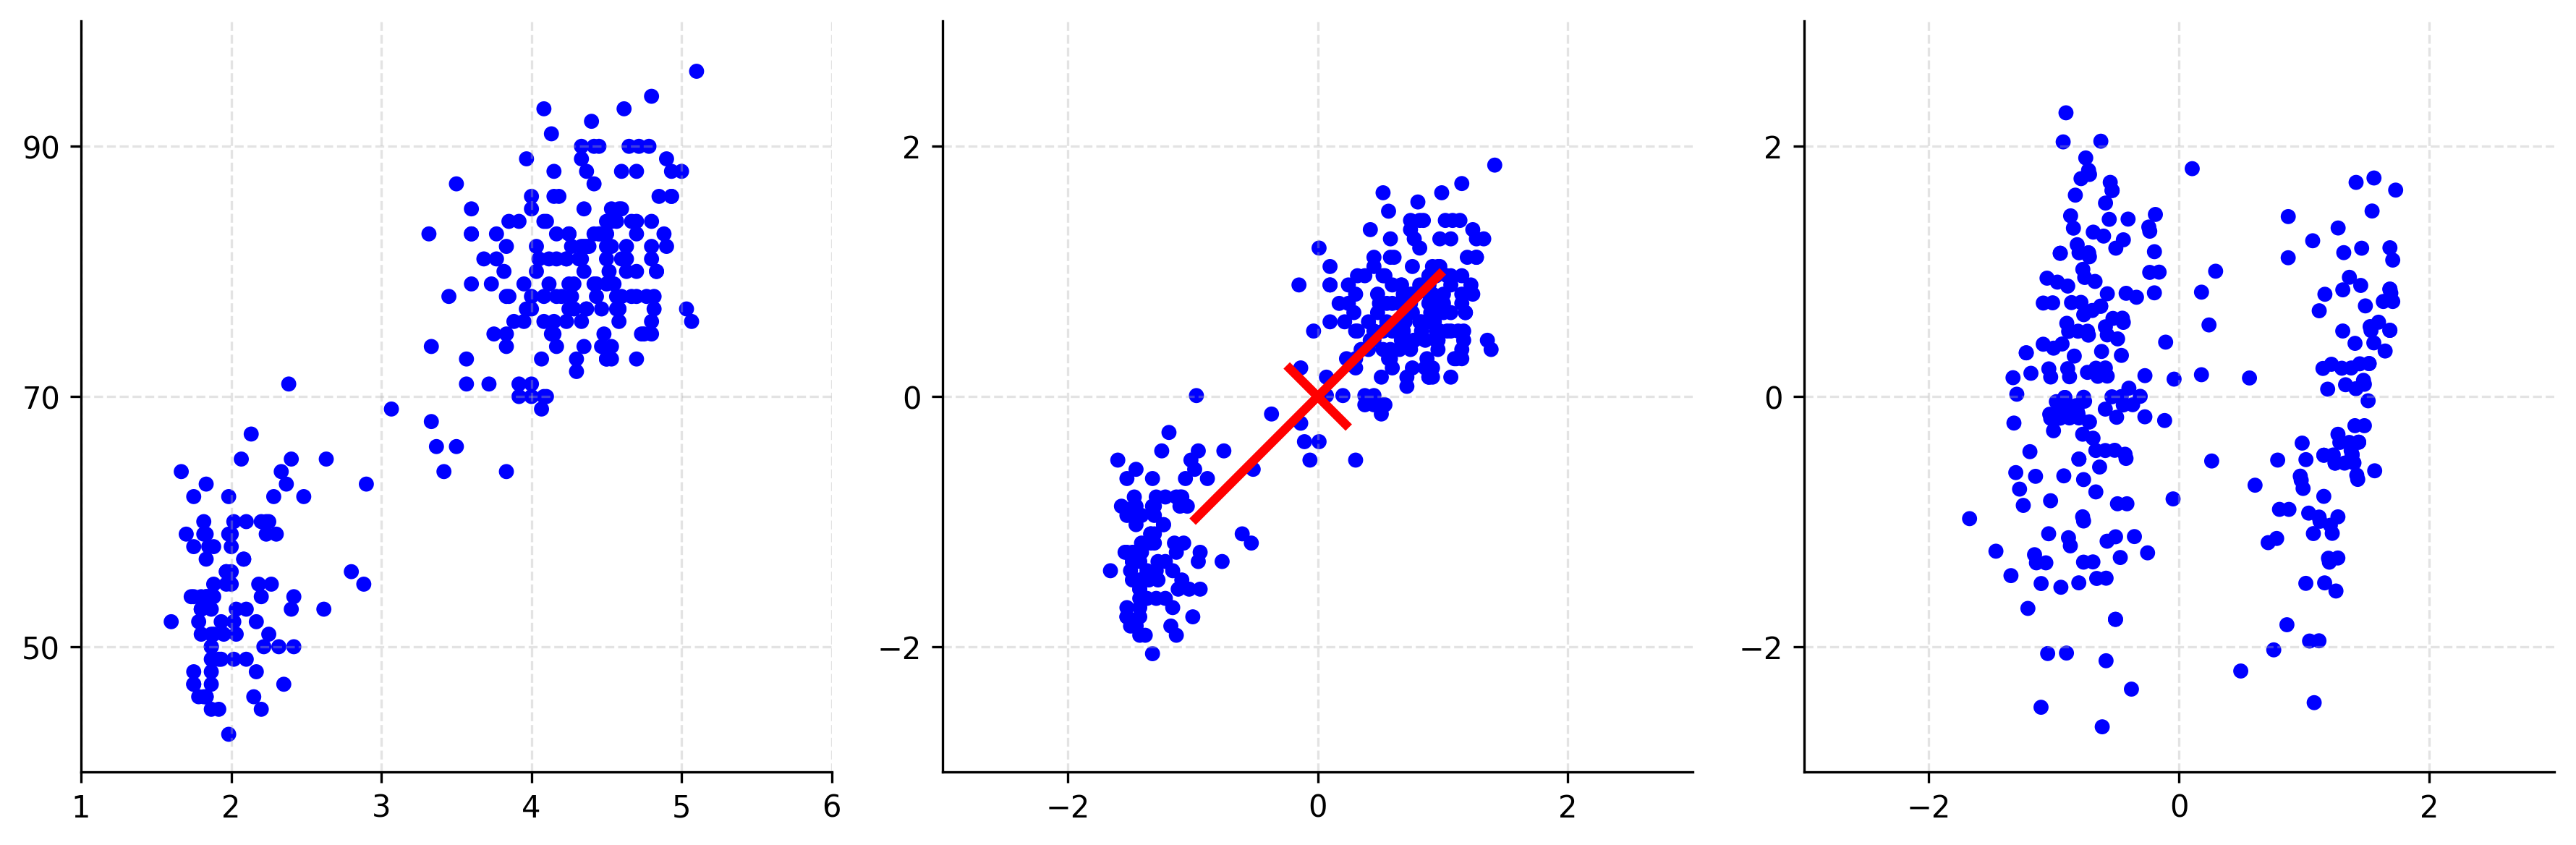

In [9]:
# Figure 16.6 の再現
fig_16_6 = generate_figure_16_6()
plt.show()


In [10]:
# 白色化変換の単位共分散性検証
from common.principal_component_analysis import whiten_data

csv_path = Path("common/data/faithful.csv") if Path("common/data/faithful.csv").exists() else Path("../common/data/faithful.csv")
df_faithful = pd.read_csv(csv_path)
X_faithful = df_faithful[["duration", "waiting"]].values

Y_white, mean_f, lambdas_f, U_f = whiten_data(X_faithful)

N = len(X_faithful)
sample_cov_white = (Y_white.T @ Y_white) / N

print(f"Whitened data shape: {Y_white.shape}")
print(f"Whitened data mean: {np.mean(Y_white, axis=0)}")
print("Whitened sample covariance matrix:")
print(sample_cov_white)

assert np.allclose(np.mean(Y_white, axis=0), 0.0, atol=1e-12)
assert np.allclose(sample_cov_white, np.eye(2), atol=1e-12)
print("Data whitening identity covariance verified to 1e-12.")


Whitened data shape: (272, 2)
Whitened data mean: [ 4.37252359e-16 -2.49800181e-16]
Whitened sample covariance matrix:
[[ 1.00000000e+00 -3.65720526e-16]
 [-3.65720526e-16  1.00000000e+00]]
Data whitening identity covariance verified to 1e-12.


## 6. 16.1.5 高次元データに対する双対PCA (High-Dimensional Data)

データ点の数 $N$ が空間の次元数 $D$ よりもはるかに小さい場合（$N < D$、例えば数百枚のメガピクセル画像 $D \sim 10^6$ に対して $N \sim 100$）、$D \times D$ の共分散行列 $\mathbf{S}$ を直接計算・対角化することは計算量 $\mathcal{O}(D^3)$ およびメモリの観点から実行不可能です。
また、$N$ 個の点によって張られる線形部分空間の次元は高々 $N - 1$ であるため、共分散行列 $\mathbf{S}$ は少なくとも $D - N + 1$ 個のゼロ固有値を持ちます。

### グラム行列トリック（双対PCA）の導出
中心化データ行列 $\mathbf{X}_c \in \mathbb{R}^{N \times D}$（第 $n$ 行が $(\mathbf{x}_n - \bar{\mathbf{x}})^\top$）を定義すると、共分散行列は $\mathbf{S} = \frac{1}{N} \mathbf{X}_c^\top \mathbf{X}_c$ と書けます。
原空間における固有方程式（式 16.26）：
$$
\frac{1}{N} \mathbf{X}_c^\top \mathbf{X}_c \mathbf{u}_i = \lambda_i \mathbf{u}_i
$$
の両辺に左から $\mathbf{X}_c$ を乗じると：
$$
\frac{1}{N} \mathbf{X}_c \mathbf{X}_c^\top (\mathbf{X}_c \mathbf{u}_i) = \lambda_i (\mathbf{X}_c \mathbf{u}_i) \quad (\text{式 } 16.27)
$$
ここで $\mathbf{v}_i \equiv \mathbf{X}_c \mathbf{u}_i \in \mathbb{R}^N$ と定義すると、**$N \times N$ の小型行列（グラム行列）に対する固有方程式**が得られます：
$$
\frac{1}{N} \mathbf{X}_c \mathbf{X}_c^\top \mathbf{v}_i = \lambda_i \mathbf{v}_i \quad (\text{式 } 16.28)
$$
この $N \times N$ 行列の対角化コストは $\mathcal{O}(N^3)$ であり、$D$ に依存しません！

### 原空間固有ベクトルの復元と正規化
式 (16.28) の両辺に左から $\mathbf{X}_c^\top$ を乗じると：
$$
\frac{1}{N} \mathbf{X}_c^\top \mathbf{X}_c (\mathbf{X}_c^\top \mathbf{v}_i) = \lambda_i (\mathbf{X}_c^\top \mathbf{v}_i) \quad (\text{式 } 16.29)
$$
となり、$\mathbf{X}_c^\top \mathbf{v}_i$ が共分散行列 $\mathbf{S}$ の固有値 $\lambda_i$ に対応する固有ベクトルであることが直ちに分かります。
$\mathbf{v}_i$ が単位ノルム（$\|\mathbf{v}_i\| = 1$）に正規化されているとき、$\mathbf{u}_i \propto \mathbf{X}_c^\top \mathbf{v}_i$ のノルムを計算すると：
$$
\|\mathbf{X}_c^\top \mathbf{v}_i\|^2 = \mathbf{v}_i^\top \mathbf{X}_c \mathbf{X}_c^\top \mathbf{v}_i = \mathbf{v}_i^\top (N \lambda_i \mathbf{v}_i) = N \lambda_i
$$
したがって、原空間における単位正規化固有ベクトル $\mathbf{u}_i$ は以下の公式で厳密に復元されます：
$$
\mathbf{u}_i = \frac{1}{\sqrt{N \lambda_i}} \mathbf{X}_c^\top \mathbf{v}_i \quad (\text{式 } 16.30)
$$


In [11]:
# 高次元データ双対PCA (N < D) の厳密な数値一致検証
rng = np.random.RandomState(42)
N_pts = 15
D_dim = 100  # N < D
X_high = rng.randn(N_pts, D_dim)

# 1. Primal PCA (D x D = 100 x 100)
pca_primal = PrincipalComponentAnalysis(n_components=5, method="primal")
pca_primal.fit(X_high)

# 2. Dual PCA (N x N = 15 x 15)
pca_dual = PrincipalComponentAnalysis(n_components=5, method="dual")
pca_dual.fit(X_high)

print(f"Data dimensions: N = {N_pts}, D = {D_dim}")
print(f"Primal eigenvalues (first 5): {pca_primal.explained_variance_}")
print(f"Dual eigenvalues   (first 5): {pca_dual.explained_variance_}")

# 固有値の一致検証
assert np.allclose(pca_primal.explained_variance_, pca_dual.explained_variance_, atol=1e-10)

# 固有ベクトルの同一部分空間張架（方向一致）検証
for i in range(5):
    cos_sim = abs(np.dot(pca_primal.components_[i], pca_dual.components_[i]))
    print(f"Component {i+1} absolute cosine similarity: {cos_sim:.8f}")
    assert np.isclose(cos_sim, 1.0, atol=1e-8)

print("Dual high-dimensional PCA Gram matrix trick verified successfully.")


Data dimensions: N = 15, D = 100
Primal eigenvalues (first 5): [13.18663978 10.35710959  8.50076629  8.24932144  7.4770865 ]
Dual eigenvalues   (first 5): [13.18663978 10.35710959  8.50076629  8.24932144  7.4770865 ]
Component 1 absolute cosine similarity: 1.00000000
Component 2 absolute cosine similarity: 1.00000000
Component 3 absolute cosine similarity: 1.00000000
Component 4 absolute cosine similarity: 1.00000000
Component 5 absolute cosine similarity: 1.00000000
Dual high-dimensional PCA Gram matrix trick verified successfully.


## 7. まとめ

本節では、第16章「連続潜在変数」の基礎となる主成分分析 (PCA) について、以下の重要な結果を厳密に導出・実装・検証しました：
1. **最大分散定式化**: 射影データの分散 $\mathbf{u}_1^\top \mathbf{S} \mathbf{u}_1$ の最大化が共分散行列の最大固有値問題に帰着すること（式 16.1 〜 16.6）。
2. **最小誤差定式化**: 射影二乗誤差 $J$ の最小化が、捨てられた固有値の和 $\sum_{i=M+1}^D \lambda_i$ に帰着し、最大分散定式化と数学的に完全一致すること（式 16.7 〜 16.18、Figure 16.2）。
3. **データ圧縮と再構成**: 手書き数字データに対する固有画像展開と再構成推移の可視化（Figure 16.3 〜 16.5）。
4. **白色化 (Whitening)**: $\mathbf{y}_n = \mathbf{L}^{-1/2} \mathbf{U}^\top (\mathbf{x}_n - \bar{\mathbf{x}})$ によるゼロ平均・単位共分散行列への線形無相関化変換（Figure 16.6）。
5. **双対PCA**: $N < D$ の高次元データにおいて、$\mathcal{O}(D^3)$ から $\mathcal{O}(N^3)$ へ計算量を削減するグラム行列トリック（式 16.26 〜 16.30）。

次節（16.2節）では、これらの非確率的PCAを線形ガウス潜在変数モデルとして確率論的に再構築する**確率的主成分分析 (Probabilistic PCA)** について学習します。
